# Lab 3 — Semantic Search

Run this notebook top to bottom as you build out `embeddings.py` and `search.py` in this same folder. See `Lab3_Instructions.md` for what belongs in each step.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the corpus, example queries, and visualization are yours to write.

In [1]:
import importlib
import search
import os
importlib.reload(search)
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from search import load_documents, build_embedding_matrix, search,pca_via_svd

## Step 1-2: Load your corpus and fetch embeddings

In [2]:
# TODO: load_documents("documents.json") and build_embedding_matrix(documents)
# Start in offline mode (the default) while you're building - switch to the real
# API once your pipeline works end to end.

documents = load_documents("documents.json")
embedding_matrix = build_embedding_matrix(documents)

print(f"Loaded {len(documents)} documents")
print(f"Topics: {sorted(set(doc['topic'] for doc in documents))}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Loaded 25 documents
Topics: ['astronomy', 'cooking', 'geography', 'music theory', 'sports']
Embedding matrix shape: (25, 1024)


In [3]:
for doc, embedding in zip(documents, embedding_matrix):
    print(f"Embedding for document {doc['id']} ({doc['topic']}):")
    print(embedding)
    print()

Embedding for document astro-1 (astronomy):
[ 0.03225708 -0.05615234 -0.05175781 ...  0.02804565 -0.02020264
 -0.01412964]

Embedding for document astro-2 (astronomy):
[ 0.01828003 -0.04437256 -0.00980377 ...  0.01622009 -0.02606201
  0.0154953 ]

Embedding for document astro-3 (astronomy):
[ 0.03013611 -0.03991699 -0.06018066 ...  0.0171814  -0.03598022
 -0.0015173 ]

Embedding for document astro-4 (astronomy):
[ 0.01038361 -0.01828003 -0.01803589 ...  0.03924561 -0.02978516
 -0.01750183]

Embedding for document astro-5 (astronomy):
[ 0.0198822  -0.00102425 -0.01062775 ...  0.00049496 -0.0152359
  0.00874329]

Embedding for document cook-1 (cooking):
[ 0.03289795 -0.01745605  0.03417969 ... -0.0194397  -0.0713501
  0.00041437]

Embedding for document cook-2 (cooking):
[-0.00120926  0.02253723 -0.02093506 ... -0.01979065 -0.0526123
  0.01238251]

Embedding for document cook-3 (cooking):
[ 0.02833557 -0.01683044 -0.02877808 ... -0.03007507 -0.0294342
  0.00301361]

Embedding for documen

## Step 3: Run a few example search queries

In [4]:
# TODO: call search(query, embedding_matrix, documents, top_k=3) with at least two
# different queries and print the results

test_queries = [
    "How do black holes form?",
    "What's the best way to cook a steak?",
]

for query in test_queries:
    print(f"\nQuery: {query!r}")
    results = search(query, embedding_matrix, documents, top_k=3)
    for doc, score in results:
        print(f"  [{score:.3f}] ({doc['topic']}) {doc['text']}")


Query: 'How do black holes form?'
  [0.261] (astronomy) Neutron stars are so dense that a teaspoon of their material would weigh billions of tons.
  [0.245] (astronomy) Saturn's rings are made mostly of ice particles, with a smaller amount of rocky debris.
  [0.210] (astronomy) A light-year measures distance, not time - it's the distance light travels in one year.

Query: "What's the best way to cook a steak?"
  [0.362] (cooking) Searing meat at high heat creates a browned crust through the Maillard reaction, adding flavor.
  [0.342] (cooking) Resting meat after cooking allows the juices to redistribute instead of spilling out when cut.
  [0.295] (cooking) Blanching vegetables briefly in boiling water then ice water helps them keep a bright color.


## Step 4: Visualize the embedding space with PCA

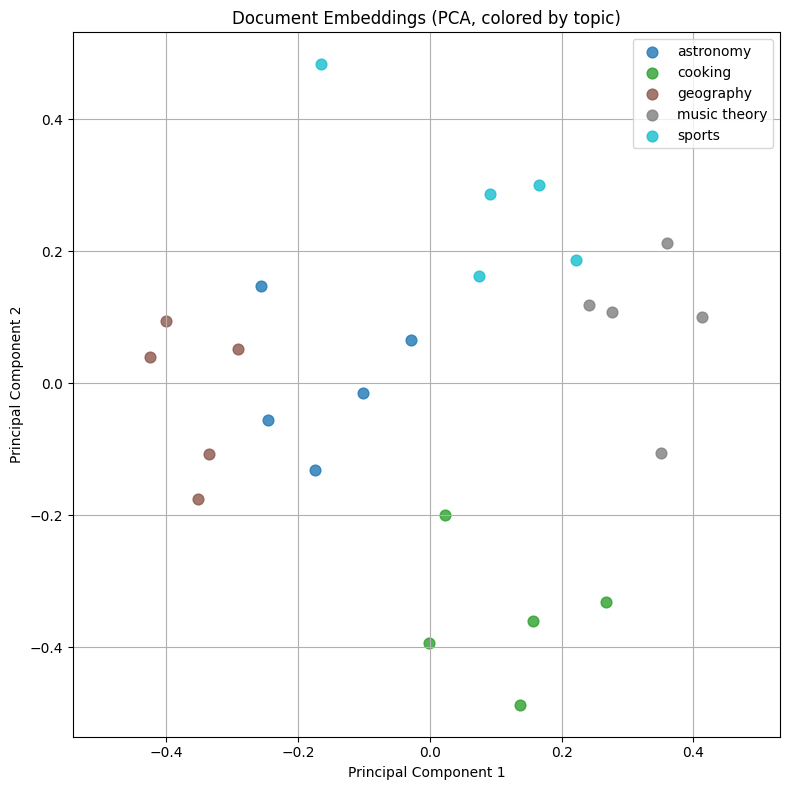

In [5]:
# TODO: reuse your Lab 2 PCA-via-SVD function (extended to 2 components) to project
# the embedding matrix down to 2D, then scatter-plot it colored by topic
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
projected, components, mean = pca_via_svd(embedding_matrix, 2)

topics = [doc["topic"] for doc in documents]
unique_topics = sorted(set(topics))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_topics)))
topic_to_color = dict(zip(unique_topics, colors))

plt.figure(figsize=(8, 8))

for topic in unique_topics:
    idx = [i for i, t in enumerate(topics) if t == topic]
    plt.scatter(
        projected[idx, 0],
        projected[idx, 1],
        color=topic_to_color[topic],
        label=topic,
        s=60,
        alpha=0.8,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Document Embeddings (PCA, colored by topic)")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "embedding_pca.png"), dpi=300, bbox_inches="tight")
plt.show()